In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../../../Data/placement_package.csv")
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 0], df.iloc[:,1],test_size=0.2,random_state=42)

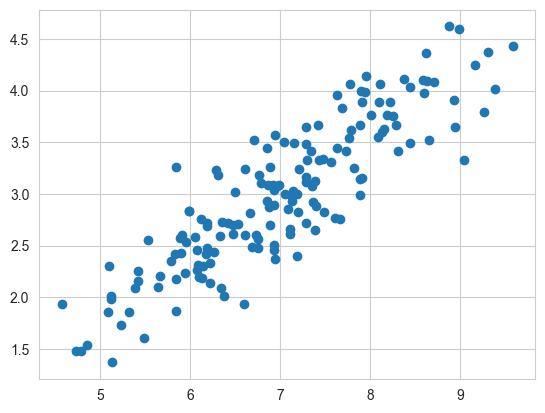

In [4]:
plt.scatter(X_train, y_train)

In [5]:
class RidgeRegressor:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None
        
    def fit(self, X_train, y_train):
        no_of_row = X_train.shape[0]
        
        numerator = 0
        denominator = 0
        
        x_mean = X_train.mean()
        y_mean = y_train.mean()
        
        for ithRow in range(no_of_row):
            numerator += (X_train.iloc[ithRow] - x_mean) * (y_train.iloc[ithRow] - y_mean)
            denominator += (X_train.iloc[ithRow] - x_mean)**2
            
        self.m = numerator / (denominator + self.alpha)
        self.b = y_mean - (self.m * x_mean)
        
    def predict(self, X_test):
        return (self.m * X_test) + self.b

In [11]:
from sklearn.metrics import r2_score
ridgeReg = RidgeRegressor(alpha=0.1)
ridgeReg.fit(X_train,y_train)
y_pred = ridgeReg.predict(X_test)
r2_score(y_test, y_pred)

0.7731426960761152

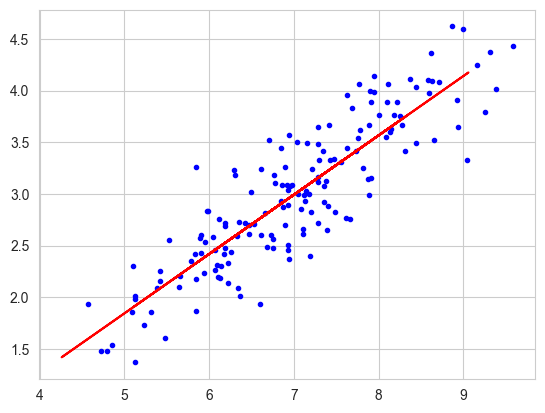

In [12]:
plt.plot(X_train, y_train, "b.")
plt.plot(X_test, y_pred, "r-")

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def regressionLineAlpha(alphas):
    
    plt.figure(figsize=(8,6))
    plt.plot(X_train, y_train, "b.", label="Training Data")
    
    result = []
    
    # generate distinct colors
    colors = plt.cm.viridis(np.linspace(0, 1, len(alphas)))
    
    for i, alpha in enumerate(alphas):
        ridgeReg = RidgeRegressor(alpha=alpha)
        ridgeReg.fit(X_train, y_train)
        y_pred = ridgeReg.predict(X_test)
        
        result.append(r2_score(y_test, y_pred))
        
        # plot with different color + label
        plt.plot(X_test, y_pred, color=colors[i], label=f'alpha={alpha}')
    
    plt.xlabel("X")
    plt.ylabel("y")
    plt.title("Ridge Regression with Different Alphas")
    plt.legend()
    plt.show()
    
    return result

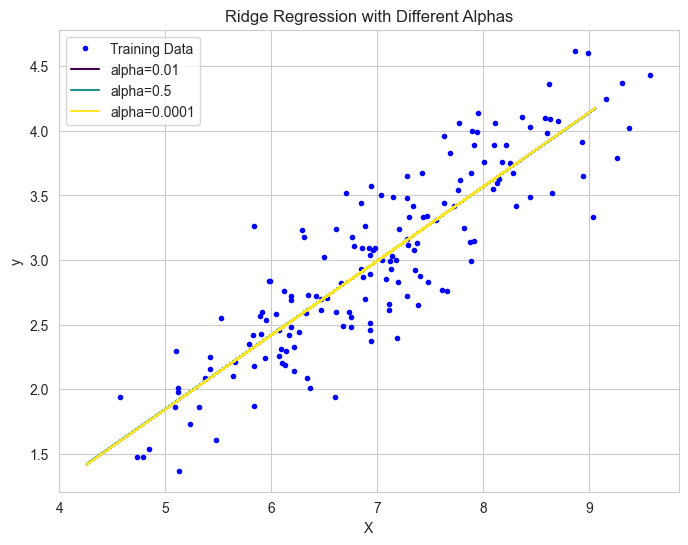

[0.7731028813735151, 0.7733145190243956, 0.7730984757329263]

In [16]:
regressionLineAlpha([0.01,0.5,0.0001])